#Computer Vision Complex Computing Activity
#Project Title: Automated Plant Disease Classifier with Filter Visualisation
23-AI-84 | 23-AI-48 |
23-AI-10 | 23-AI-56

LIBRARIES


In [ ]:
import random
import numpy as np
import pandas as pd
import cv2
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, Flatten, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
import time


LOAD DATASET FROM KAGGLE

In [ ]:
!pip install kaggle -q

from google.colab import userdata

os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

DOWNLOAD_DIR = '/content/new_plant_diseases_dataset'
os.makedirs(DOWNLOAD_DIR, exist_ok=True)

os.system(f'kaggle datasets download -d vipoooool/new-plant-diseases-dataset -p {DOWNLOAD_DIR}')
os.system(f'unzip -q {DOWNLOAD_DIR}/new-plant-diseases-dataset.zip -d {DOWNLOAD_DIR}')
print("Dataset ready ")

Dataset ready 


GPU INFORMATION

In [ ]:

print("GPUs available:", tf.config.list_physical_devices('GPU'))
print("TensorFlow version:", tf.__version__)


GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TensorFlow version: 2.20.0


DATASET PATH AND PARAMETERS

In [ ]:
IMG_SIZE   = (128, 128)
BATCH_SIZE = 64
TRAIN_DIR  = '/content/new_plant_diseases_dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train'
VAL_DIR    = '/content/new_plant_diseases_dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid'


LOAD DATASET

In [ ]:
train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=True,
    seed=42
)
val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=False
)

Found 70295 files belonging to 38 classes.
Found 17572 files belonging to 38 classes.


CLASS INFORMATION

In [ ]:

class_names = train_ds_raw.class_names
NUM_CLASSES = len(class_names)

print(f"Total Classes: {NUM_CLASSES}")
for i, name in enumerate(class_names):
    print(f"  [{i:02d}] {name}")


Total Classes: 38
  [00] Apple___Apple_scab
  [01] Apple___Black_rot
  [02] Apple___Cedar_apple_rust
  [03] Apple___healthy
  [04] Blueberry___healthy
  [05] Cherry_(including_sour)___Powdery_mildew
  [06] Cherry_(including_sour)___healthy
  [07] Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
  [08] Corn_(maize)___Common_rust_
  [09] Corn_(maize)___Northern_Leaf_Blight
  [10] Corn_(maize)___healthy
  [11] Grape___Black_rot
  [12] Grape___Esca_(Black_Measles)
  [13] Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
  [14] Grape___healthy
  [15] Orange___Haunglongbing_(Citrus_greening)
  [16] Peach___Bacterial_spot
  [17] Peach___healthy
  [18] Pepper,_bell___Bacterial_spot
  [19] Pepper,_bell___healthy
  [20] Potato___Early_blight
  [21] Potato___Late_blight
  [22] Potato___healthy
  [23] Raspberry___healthy
  [24] Soybean___healthy
  [25] Squash___Powdery_mildew
  [26] Strawberry___Leaf_scorch
  [27] Strawberry___healthy
  [28] Tomato___Bacterial_spot
  [29] Tomato___Early_blight
  [30] T

DISPLAY SAMPLE IMAGE

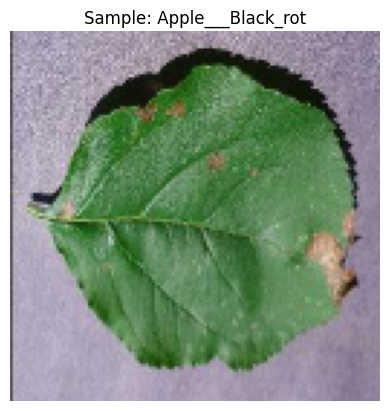

In [ ]:

for images, labels in train_ds_raw.take(1):
    img = images[0].numpy().astype("uint8")
    label_idx = labels[0].numpy()

plt.imshow(img)
plt.title(f"Sample: {class_names[label_idx]}")
plt.axis("off")
plt.show()


IMAGE PREPROCESSING

In [ ]:
def process_image(img_path, save_path=None):

    # load image
    img = cv2.imread(img_path)

    # resize
    img = cv2.resize(img, IMG_SIZE)

    # BGR TO RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    # save processed image
    if save_path:

        cv2.imwrite(
            save_path,
            cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
        )

    return img

SOBEL AND LAPLACIAN FILTERS

In [ ]:
def apply_filters(image):
    gray      = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    sobel_x   = cv2.filter2D(gray, -1, np.array([[-1,0,1],[-2,0,2],[-1,0,1]]))
    sobel_y   = cv2.filter2D(gray, -1, np.array([[-1,-2,-1],[0,0,0],[1,2,1]]))
    laplacian = cv2.filter2D(gray, -1, np.array([[0,1,0],[1,-4,1],[0,1,0]]))
    return sobel_x, sobel_y, laplacian

VISUALIZE FILTERS ON RANDOM CLASSES

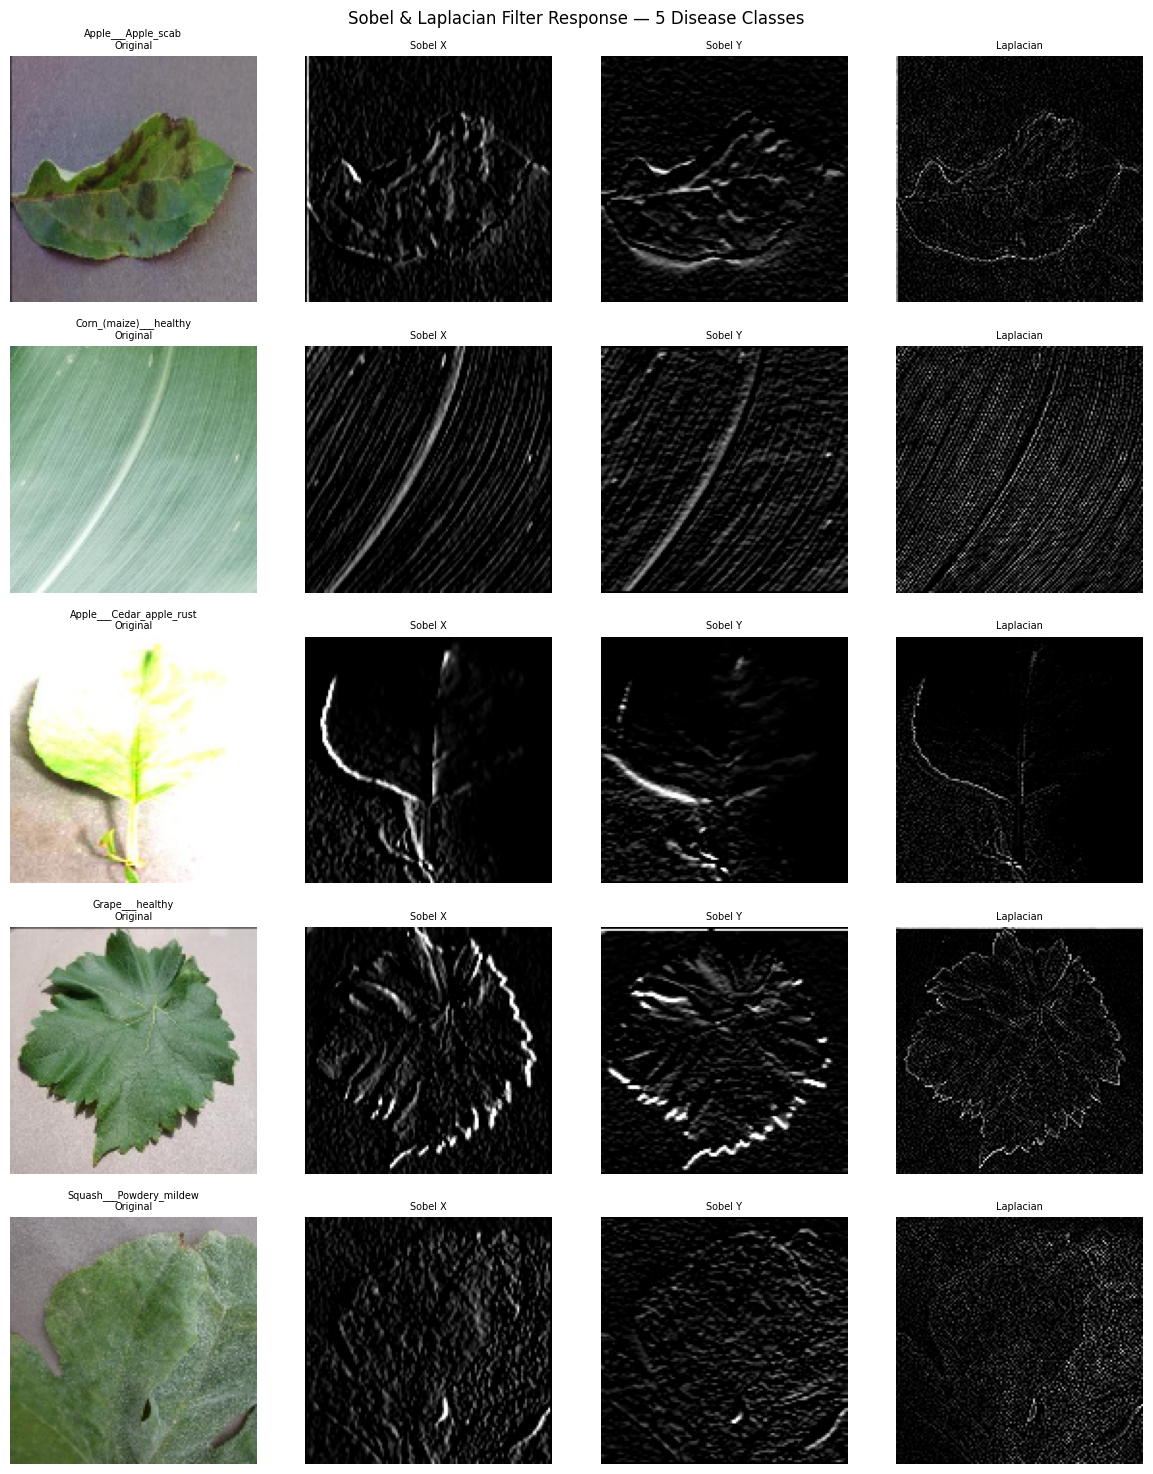

In [ ]:

selected_indices = random.sample(range(NUM_CLASSES), 5)

plt.figure(figsize=(12, 15))

for plot_i, class_idx in enumerate(selected_indices):

    # class name
    class_name = class_names[class_idx]

    # class folder path
    class_folder = os.path.join(TRAIN_DIR, class_name)

    # pick one image
    image_name = os.listdir(class_folder)[0]

    # full image path
    image_path = os.path.join(class_folder, image_name)

    # USE CUSTOM PROCESS FUNCTION
    img_r = process_image(image_path)

    # apply filters
    sx, sy, lap = apply_filters(img_r)

    # ORIGINAL
    plt.subplot(5, 4, plot_i*4 + 1)
    plt.imshow(img_r)
    plt.title(f"{class_name}\nOriginal", fontsize=7)
    plt.axis("off")

    # SOBEL X
    plt.subplot(5, 4, plot_i*4 + 2)
    plt.imshow(sx, cmap='gray')
    plt.title("Sobel X", fontsize=7)
    plt.axis("off")

    # SOBEL Y
    plt.subplot(5, 4, plot_i*4 + 3)
    plt.imshow(sy, cmap='gray')
    plt.title("Sobel Y", fontsize=7)
    plt.axis("off")

    # LAPLACIAN
    plt.subplot(5, 4, plot_i*4 + 4)
    plt.imshow(lap, cmap='gray')
    plt.title("Laplacian", fontsize=7)
    plt.axis("off")

plt.suptitle(
    "Sobel & Laplacian Filter Response — 5 Disease Classes",
    fontsize=12
)

plt.tight_layout()
plt.show()

DATA AUGMENTATION

In [ ]:
augment   = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
])

NORMALIZATION

In [ ]:
normalize = layers.Rescaling(1./255)

PREPARE DATASET

In [ ]:

train_ds = (train_ds_raw
            .map(lambda x, y: (normalize(augment(x, training=True)), y), num_parallel_calls=tf.data.AUTOTUNE)
            .prefetch(tf.data.AUTOTUNE))

val_ds   = (val_ds_raw
            .map(lambda x, y: (normalize(x), y), num_parallel_calls=tf.data.AUTOTUNE)
            .prefetch(tf.data.AUTOTUNE))

print("Pipeline ready ")


Pipeline ready 


BULID CNN ARCHITECTURE


In [ ]:
cnn_model = models.Sequential([
    Conv2D(32,  (3,3), padding='same', activation='relu', input_shape=(128,128,3), name='conv1'),
    BatchNormalization(), MaxPooling2D(), Dropout(0.25),

    Conv2D(64,  (3,3), padding='same', activation='relu', name='conv2'),
    BatchNormalization(), MaxPooling2D(), Dropout(0.25),

    Conv2D(128, (3,3), padding='same', activation='relu', name='conv3'),
    BatchNormalization(), MaxPooling2D(), Dropout(0.25),

    Flatten(),
    Dense(256, activation='relu'),
    BatchNormalization(), Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
], name='CNN_from_Scratch')

cnn_model.summary()



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "CNN_from_Scratch"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,493,798 (32.40 MB)

 Trainable params: 8,492,838 (32.40 MB)

 Non-trainable params: 960 (3.75 KB)

COMPILE, TRAIN & PLOT CURVES

Epoch 1/5
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 319s 278ms/step - accuracy: 0.6396 - loss: 1.2320 - val_accuracy: 0.5790 - val_loss: 1.6050 - learning_rate: 0.0010
Epoch 2/5
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 301s 274ms/step - accuracy: 0.8484 - loss: 0.4787 - val_accuracy: 0.4027 - val_loss: 4.8604 - learning_rate: 0.0010
Epoch 3/5
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 357s 325ms/step - accuracy: 0.8931 - loss: 0.3388 - val_accuracy: 0.4505 - val_loss: 4.6719 - learning_rate: 0.0010
Epoch 4/5
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 292s 265ms/step - accuracy: 0.9093 - loss: 0.2823 - val_accuracy: 0.8284 - val_loss: 0.7016 - learning_rate: 0.0010
Epoch 5/5
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 294s 267ms/step - accuracy: 0.9208 - loss: 0.2415 - val_accuracy: 0.5892 - val_loss: 1.8795 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 4.
Best val accuracy : 82.84%  |  Params: 8,493,798  |  Time: 26.1 min


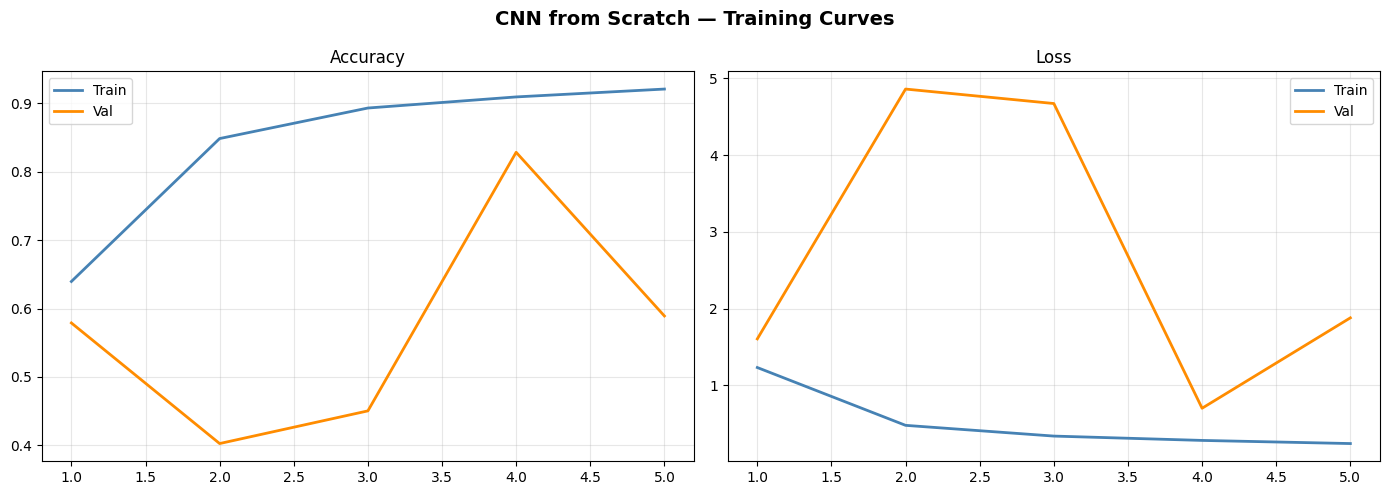

In [ ]:
cnn_model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])

t0 = time.time()
cnn_history = cnn_model.fit(
    train_ds, validation_data=val_ds, epochs=5,
    callbacks=[
        EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
    ], verbose=1
)
m2_time     = time.time() - t0
m2_val_acc  = max(cnn_history.history['val_accuracy'])
m2_params   = cnn_model.count_params()
m2_epochs   = len(cnn_history.history['val_accuracy'])

print(f"Best val accuracy : {m2_val_acc*100:.2f}%  |  Params: {m2_params:,}  |  Time: {m2_time/60:.1f} min")
plot_curves(cnn_history, "CNN from Scratch — Training Curves")


FEATURE MAP VISULAIZATION

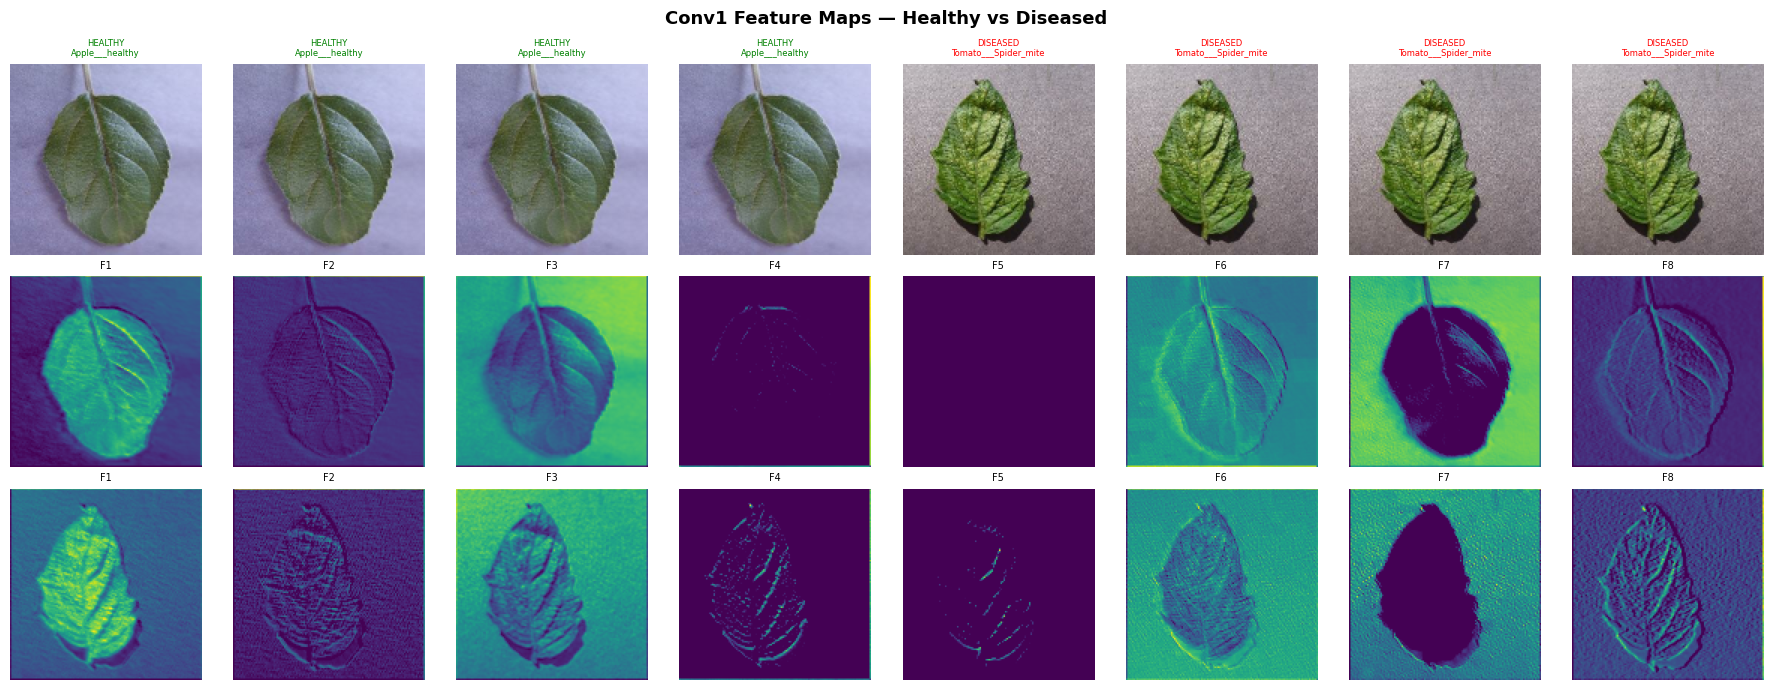

In [ ]:
inp = tf.keras.Input(shape=(128, 128, 3))
x = inp
for layer in cnn_model.layers:
    x = layer(x)
    if layer.name == 'conv1':
        break
feat_model = tf.keras.Model(inputs=inp, outputs=x)

healthy_idx  = [i for i, n in enumerate(class_names) if 'healthy' in n.lower()]
diseased_idx = [i for i, n in enumerate(class_names) if 'healthy' not in n.lower()]
healthy_img = diseased_img = None

for images, labels in train_ds_raw.unbatch():
    lbl = labels.numpy()
    img_r = tf.image.resize(images, IMG_SIZE).numpy() / 255.0
    if healthy_img  is None and lbl in healthy_idx:  healthy_img  = img_r; healthy_lbl  = class_names[lbl]
    if diseased_img is None and lbl in diseased_idx: diseased_img = img_r; diseased_lbl = class_names[lbl]
    if healthy_img is not None and diseased_img is not None:
        break

h_fmaps = feat_model.predict(tf.expand_dims(healthy_img,  0), verbose=0)[0]
d_fmaps = feat_model.predict(tf.expand_dims(diseased_img, 0), verbose=0)[0]

n_maps = 8
fig, axes = plt.subplots(3, n_maps, figsize=(18, 7))
fig.suptitle("Conv1 Feature Maps — Healthy vs Diseased", fontsize=13, fontweight='bold')
for col in range(n_maps):
    is_h = col < n_maps // 2
    axes[0, col].imshow(healthy_img if is_h else diseased_img)
    axes[0, col].set_title(f"{'HEALTHY' if is_h else 'DISEASED'}\n{(healthy_lbl if is_h else diseased_lbl)[:20]}", fontsize=6, color='green' if is_h else 'red')
    axes[0, col].axis('off')
    axes[1, col].imshow(h_fmaps[:, :, col], cmap='viridis'); axes[1, col].set_title(f"F{col+1}", fontsize=7); axes[1, col].axis('off')
    axes[2, col].imshow(d_fmaps[:, :, col], cmap='viridis'); axes[2, col].set_title(f"F{col+1}", fontsize=7); axes[2, col].axis('off')
axes[1, 0].set_ylabel("Healthy", fontsize=9)
axes[2, 0].set_ylabel("Diseased", fontsize=9)
plt.tight_layout(); plt.show()

SAVE MODEL

In [ ]:
Cnn_model.save('model_A_cnn_scratch.keras')
print("CNN saved ")


CNN saved 


#Application of Pre-trained Model
Using MobileNetV2

Model A: MobileNetV2 ( Fully Frozen )

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "MobileNetV2_Frozen"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 224)            │       286,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 224)            │           896 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 224)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 38)             │         8,550 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,554,374 (9.74 MB)

 Trainable params: 295,942 (1.13 MB)

 Non-trainable params: 2,258,432 (8.62 MB)

Epoch 1/5
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 374s 323ms/step - accuracy: 0.8003 - loss: 0.6627 - val_accuracy: 0.8630 - val_loss: 0.4276
Epoch 2/5
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 356s 324ms/step - accuracy: 0.8711 - loss: 0.3997 - val_accuracy: 0.8688 - val_loss: 0.3981
Epoch 3/5
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 299s 272ms/step - accuracy: 0.8800 - loss: 0.3655 - val_accuracy: 0.8828 - val_loss: 0.3608
Epoch 4/5
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 317s 268ms/step - accuracy: 0.8878 - loss: 0.3413 - val_accuracy: 0.8744 - val_loss: 0.3717
Epoch 5/5
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 329s 275ms/step - accuracy: 0.8912 - loss: 0.3285 - val_accuracy: 0.8828 - val_loss: 0.3479
Restoring model weights from the end of the best epoch: 5.
Best val accuracy : 88.28%  |  Params: 2,554,374  |  Time: 28.3 min


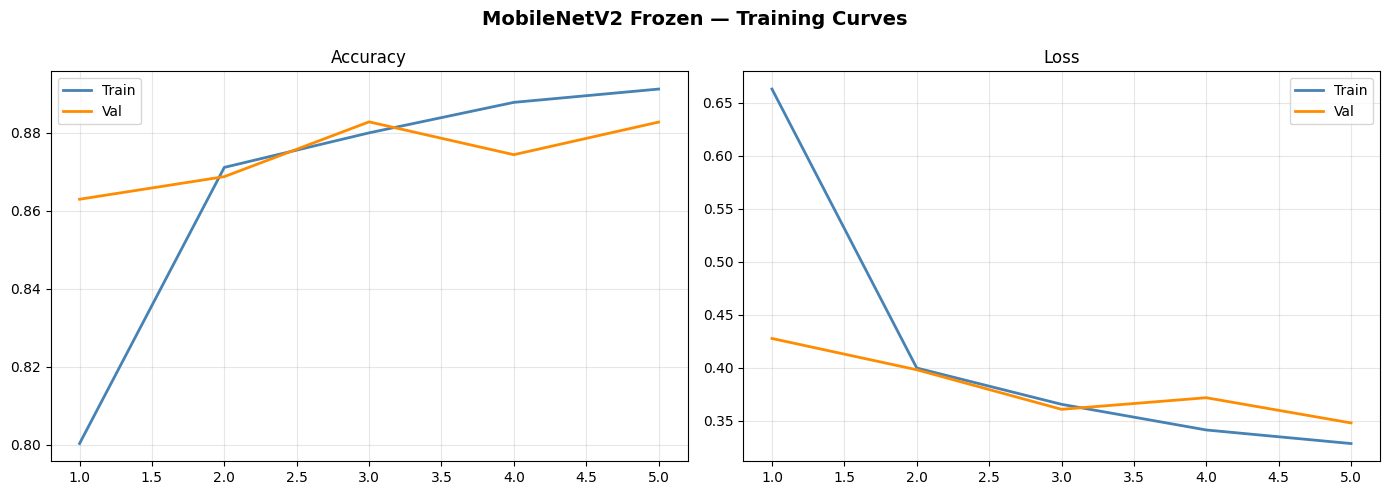

In [ ]:
#Freezing all base layer and training only the classifier head custom to plant disease dataset.

#LOADING PRETRAINED FROZEN MODEL (MobileNetV2)

#include_top = False removes the ImageNet classification Layer.
#trainable = False freezes alll base layers so that no weights get updated
base_model = MobileNetV2(input_shape=(128,128,3), include_top=False, weights='imagenet')
base_model.trainable = False


#BUILDING FULLL MODEL WITH CUSTOM CLASSIDIER HEAD

frozen_model = models.Sequential([
    #for feature extraction
    base_model,

    #Reduces spatical dimensions
    GlobalAveragePooling2D(),

    #Fully connected layer
    Dense(224, activation='relu'),

    #to speed up convergence,stabilize activation
    BatchNormalization(),

    #randomly drops 40% of neurons
    Dropout(0.4),

    # Output: probability distribution over disease classes
    Dense(NUM_CLASSES, activation='softmax')
], name='MobileNetV2_Frozen')

#COMPILING THE MODEL

#using Adam with default lr = 1e-3.
#using sparse categorical crossentropy because indices are integers.
frozen_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
frozen_model.summary() #to print the architecture layer by layer


#TRAINIG THE MODEL

#Starting timer for total duration
t0 = time.time()

#alying Earlystopping with 5 epoch patience level
frozen_history = frozen_model.fit(
    train_ds, validation_data=val_ds, epochs=5,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)],
    verbose=1
)

#total training time
frozen_time   = time.time() - t0

#Best validation accuracy
frozen_val_acc = max(frozen_history.history['val_accuracy'])

#Total number of parameters
frozen_params  = frozen_model.count_params()

#number of Epochs run
frozen_epochs  = len(frozen_history.history['val_accuracy'])


#visualising the model
print(f"Best val accuracy : {frozen_val_acc*100:.2f}%  |  Params: {frozen_params:,}  |  Time: {frozen_time/60:.1f} min")
plot_curves(frozen_history, "MobileNetV2 Frozen — Training Curves")



Save model

In [ ]:
frozen_model.save('modelA_frozen.keras')
print("Frozen model saved ")

Frozen model saved 


Model B: Fine-tuned MobileNetV2 with 30 trainable layers

Trainable layers: 30 / 154
Epoch 1/5
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 333s 286ms/step - accuracy: 0.8041 - loss: 0.6314 - val_accuracy: 0.8631 - val_loss: 0.4197 - learning_rate: 1.0000e-05
Epoch 2/5
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 353s 321ms/step - accuracy: 0.8716 - loss: 0.3920 - val_accuracy: 0.8939 - val_loss: 0.3138 - learning_rate: 1.0000e-05
Epoch 3/5
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 298s 271ms/step - accuracy: 0.8933 - loss: 0.3200 - val_accuracy: 0.9059 - val_loss: 0.2780 - learning_rate: 1.0000e-05
Epoch 4/5
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 291s 264ms/step - accuracy: 0.9065 - loss: 0.2828 - val_accuracy: 0.9136 - val_loss: 0.2534 - learning_rate: 1.0000e-05
Epoch 5/5
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 292s 265ms/step - accuracy: 0.9185 - loss: 0.2458 - val_accuracy: 0.9206 - val_loss: 0.2339 - learning_rate: 1.0000e-05
Restoring model weights from the end of the best epoch: 5.
Best val accuracy : 92.06%  |  Params: 2,554,374  |  Time: 26.1 min


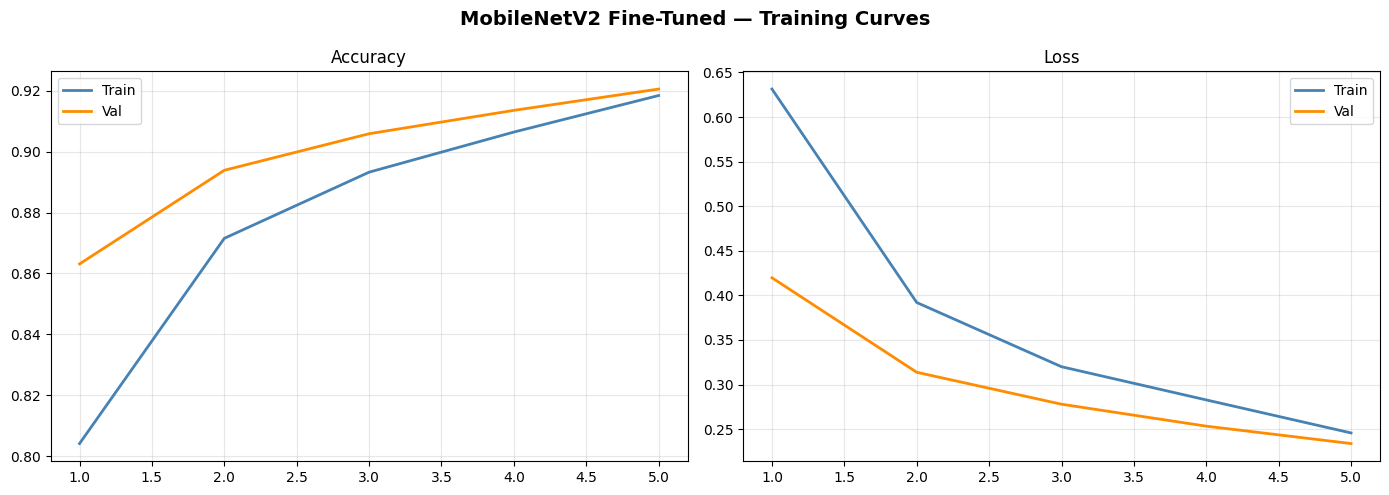

In [ ]:
#unfreezing labst 30 layers of base model to train them on Plant diease data

#UNFREEZE THE TOP LAYERS OF THE MODEL

#Eable ttraining for base model
base_model.trainable = True

#Freeze all except the last 30
for layer in base_model.layers[:-30]:
    layer.trainable = False

print(f"Trainable layers: {sum(1 for l in base_model.layers if l.trainable)} / {len(base_model.layers)}")

model_B = frozen_model #model_B has same architecture as base_model

#Re-compiling because layer trainability was changed
#lr = 1e-5 to avid destruction pre-trained weights
model_B.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
                loss='sparse_categorical_crossentropy', metrics=['accuracy'])

#TRAINING

#using ReduceLROnPlateau to preserve pre-traiined weights.minimum lr = 1e-7
t0 = time.time()
ft_history = model_B.fit(
    train_ds, validation_data=val_ds, epochs=5,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1)
    ], verbose=1
)
ft_time    = time.time() - t0
ft_val_acc = max(ft_history.history['val_accuracy'])
ft_params  = model_B.count_params()
ft_epochs  = len(ft_history.history['val_accuracy'])

#Visualise model_B
print(f"Best val accuracy : {ft_val_acc*100:.2f}%  |  Params: {ft_params:,}  |  Time: {ft_time/60:.1f} min")
plot_curves(ft_history, "MobileNetV2 Fine-Tuned — Training Curves")



Save model_B

In [ ]:
model_B.save('modelB_trainable.keras')
print("Fine-tuned model saved")

Fine-tuned model saved


# Model Comparison & Best Model Selection

In [ ]:

comparison_df = pd.DataFrame([
    {'Model': 'CNN from Scratch (M2)',       'Val Accuracy (%)': round(m2_val_acc*100, 2),     'Parameters': m2_params,    'Time (min)': round(m2_time/60, 1),     'Epochs': m2_epochs},
    {'Model': 'MobileNetV2 Frozen (M3)',     'Val Accuracy (%)': round(frozen_val_acc*100, 2), 'Parameters': frozen_params,'Time (min)': round(frozen_time/60, 1), 'Epochs': frozen_epochs},
    {'Model': 'MobileNetV2 Fine-Tuned (M3)', 'Val Accuracy (%)': round(ft_val_acc*100, 2),     'Parameters': ft_params,    'Time (min)': round(ft_time/60, 1),     'Epochs': ft_epochs},
])
print("\n", comparison_df.to_string(index=False))

# Save best model
best = max({'CNN from Scratch (M2)': m2_val_acc, 'MobileNetV2 Frozen (M3)': frozen_val_acc, 'MobileNetV2 Fine-Tuned (M3)': ft_val_acc}, key=lambda k: {'CNN from Scratch (M2)': m2_val_acc, 'MobileNetV2 Frozen (M3)': frozen_val_acc, 'MobileNetV2 Fine-Tuned (M3)': ft_val_acc}[k])
model_map = {'CNN from Scratch (M2)': cnn_model, 'MobileNetV2 Frozen (M3)': frozen_model, 'MobileNetV2 Fine-Tuned (M3)': model_B}

SAVE_PATH = '/content/drive/MyDrive/PlantDisease/best_model.keras'
os.makedirs(os.path.dirname(SAVE_PATH), exist_ok=True)
model_map[best].save(SAVE_PATH)

with open('/content/drive/MyDrive/PlantDisease/class_names.txt', 'w') as f:
    f.write('\n'.join(class_names))

print(f"\nBest model : {best}")
print(f"Saved to   : {SAVE_PATH}")




                       Model  Val Accuracy (%)  Parameters  Time (min)  Epochs
      CNN from Scratch (M2)             82.84     8493798        26.1       5
    MobileNetV2 Frozen (M3)             88.28     2554374        28.3       5
MobileNetV2 Fine-Tuned (M3)             92.06     2554374        26.1       5

Best model : MobileNetV2 Fine-Tuned (M3)
Saved to   : /content/drive/MyDrive/PlantDisease/best_model.keras


# Validation Set Inference & Overall Performance Evaluation

In [ ]:
print("\n  Running inference on validation set...")
y_true, y_pred = [], []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

overall_acc = accuracy_score(y_true, y_pred)
overall_f1  = f1_score(y_true, y_pred, average='weighted')
print(f"\n Overall Accuracy : {overall_acc*100:.2f}%")
print(f" Weighted F1 Score: {overall_f1:.4f}")


  Running inference on validation set...

 Overall Accuracy : 92.06%
 Weighted F1 Score: 0.9206


# Confusion Matrix Visualization (38 Classes)


 Plotting Confusion Matrix...


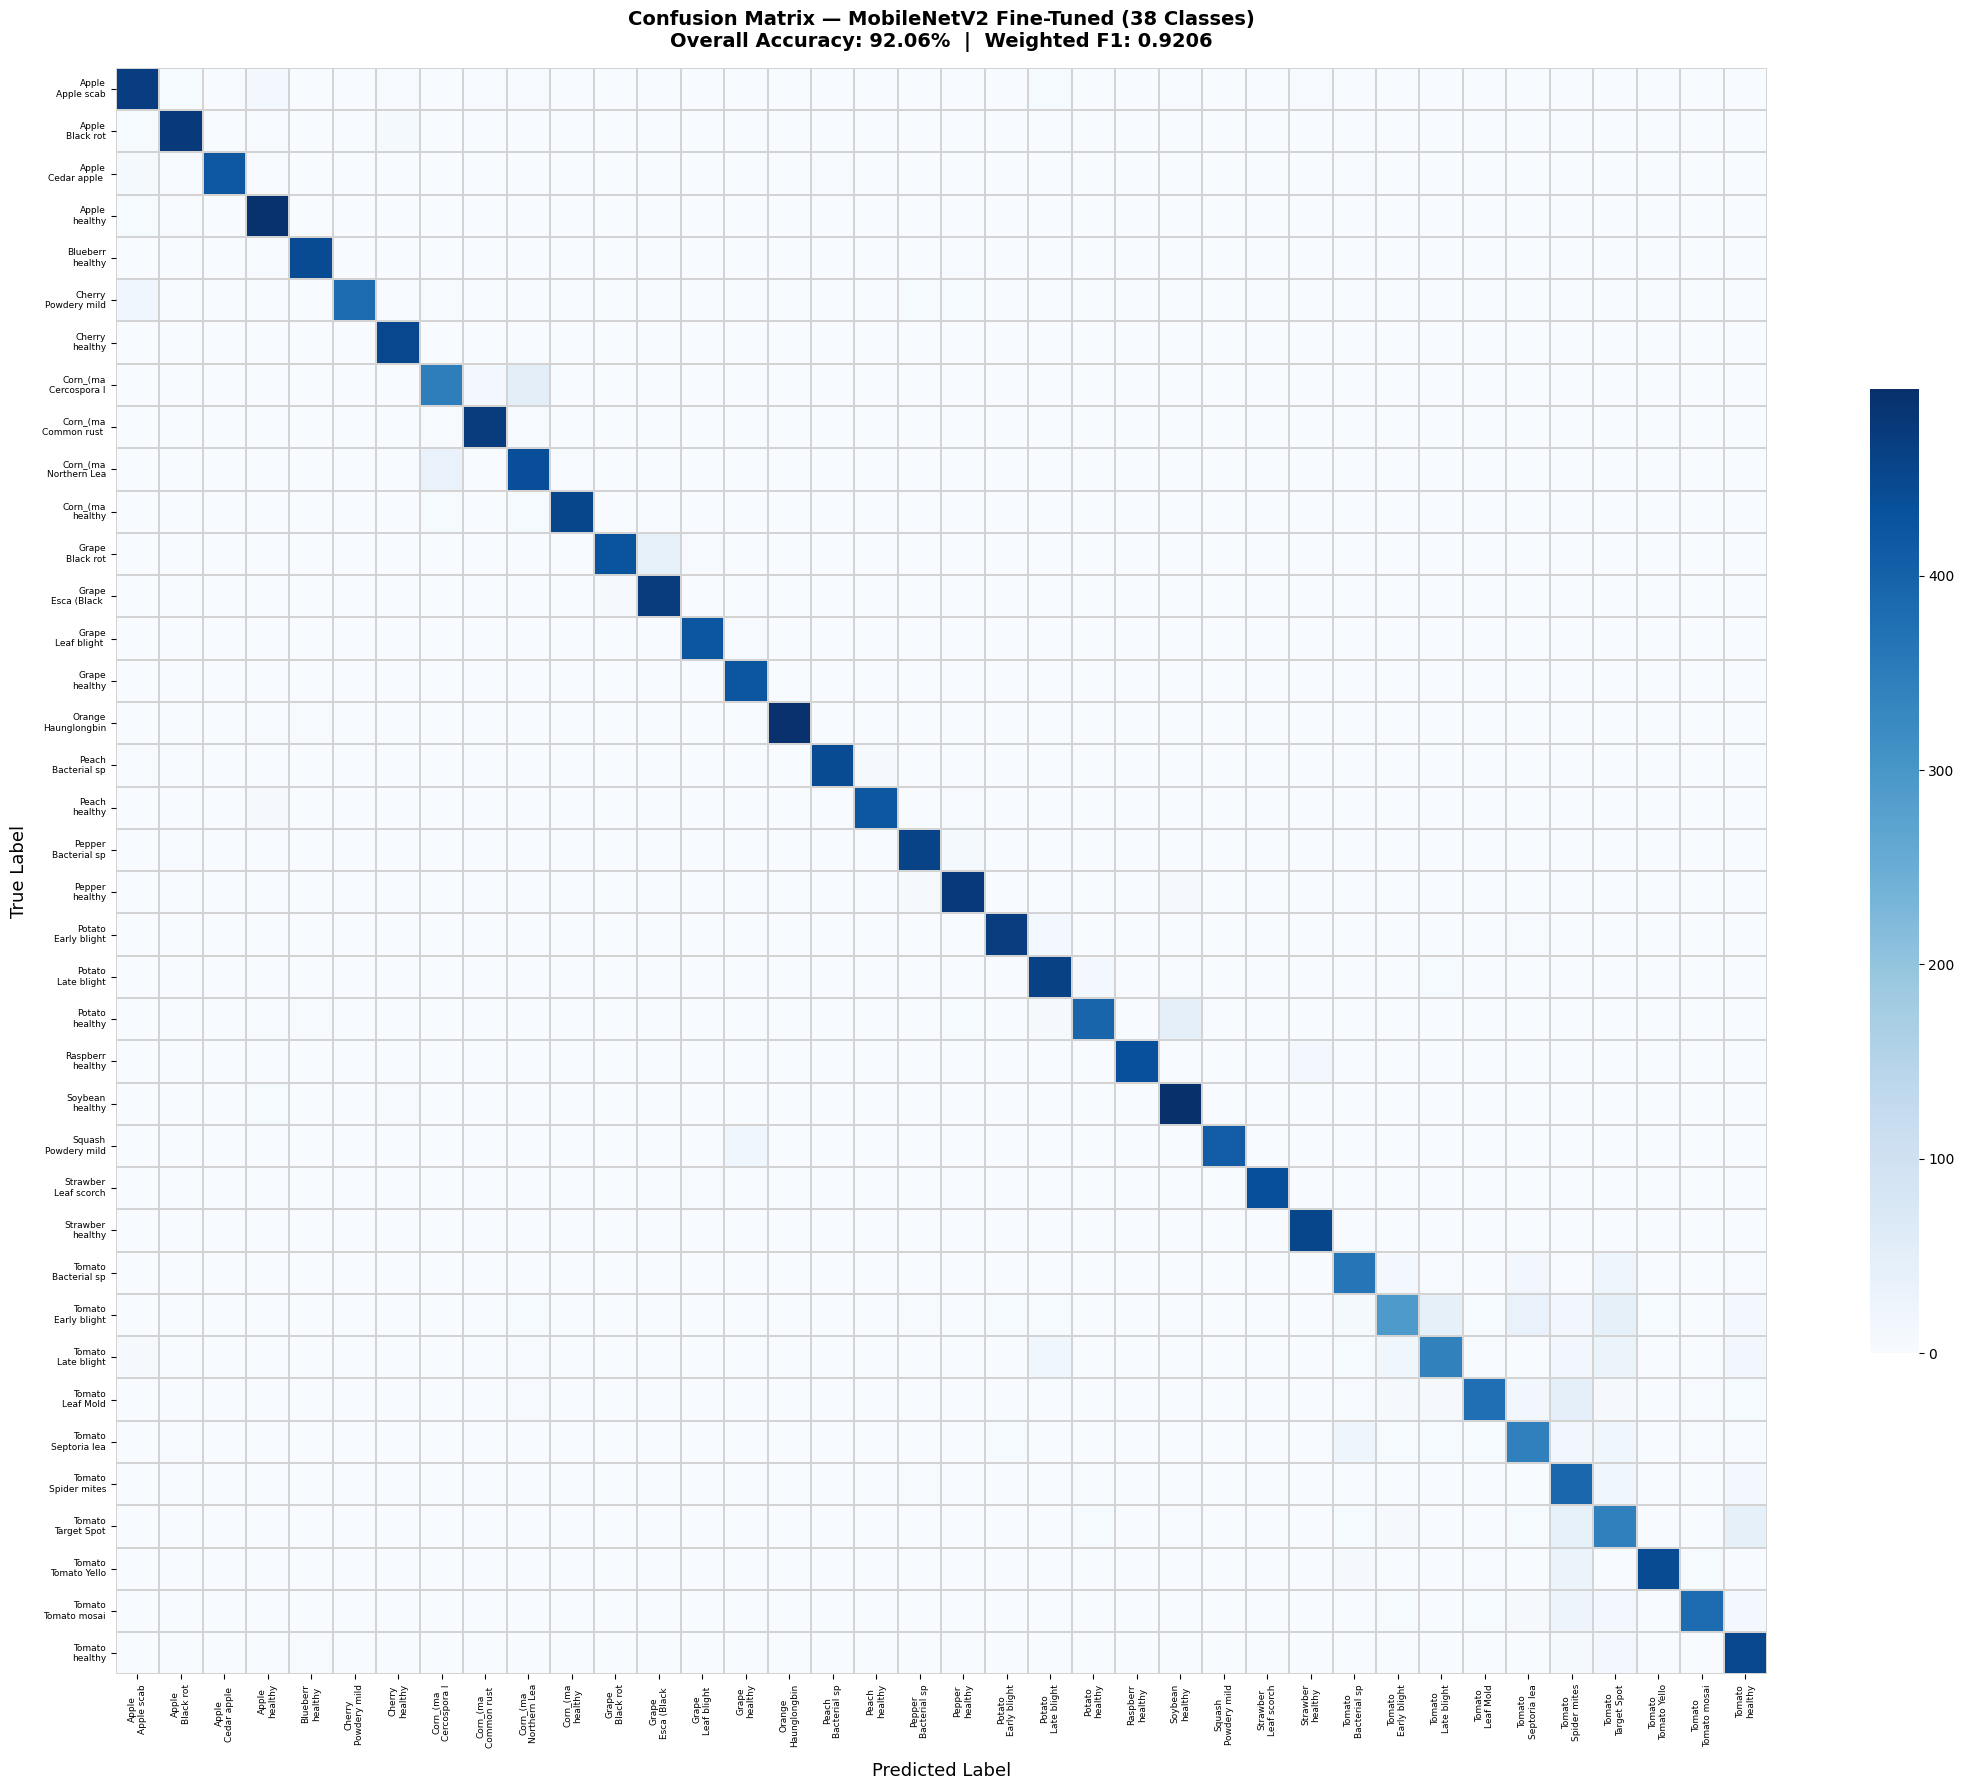

 Confusion matrix saved


In [ ]:
print("\n Plotting Confusion Matrix...")

cm = confusion_matrix(y_true, y_pred)

# Short labels for readability
short_labels = []
for name in class_names:
    parts = name.split('___')
    plant   = parts[0].replace('_(including_sour)', '').replace(',_bell', '').strip()
    disease = parts[1].replace('_', ' ') if len(parts) > 1 else ''
    short_labels.append(f"{plant[:8]}\n{disease[:12]}")

fig, ax = plt.subplots(figsize=(22, 18))
sns.heatmap(
    cm, annot=False, fmt='d', cmap='Blues',
    xticklabels=short_labels, yticklabels=short_labels,
    linewidths=0.3, linecolor='lightgray',
    cbar_kws={'shrink': 0.6}
)
ax.set_xlabel('Predicted Label', fontsize=13, labelpad=10)
ax.set_ylabel('True Label', fontsize=13, labelpad=10)
ax.set_title(
    f'Confusion Matrix — MobileNetV2 Fine-Tuned (38 Classes)\n'
    f'Overall Accuracy: {overall_acc*100:.2f}%  |  Weighted F1: {overall_f1:.4f}',
    fontsize=14, fontweight='bold', pad=15
)
ax.tick_params(axis='x', rotation=90, labelsize=6.5)
ax.tick_params(axis='y', rotation=0,  labelsize=6.5)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/PlantDisease/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Confusion matrix saved")

# Per-Class Accuracy Bar Chart

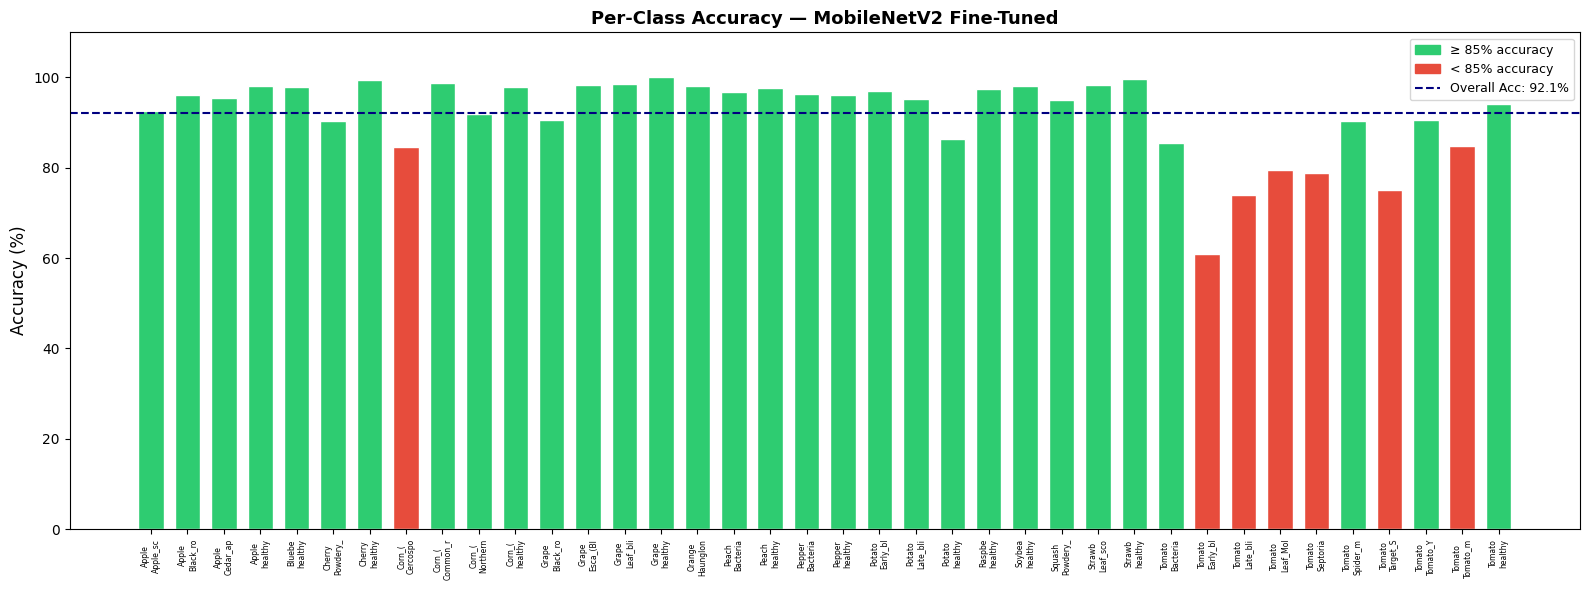

 Per-class accuracy chart saved


In [ ]:
per_class_acc = cm.diagonal() / cm.sum(axis=1)

fig, ax = plt.subplots(figsize=(16, 6))
colors = ['#e74c3c' if a < 0.85 else '#2ecc71' for a in per_class_acc]
bars = ax.bar(range(NUM_CLASSES), per_class_acc * 100, color=colors, edgecolor='white', width=0.7)
ax.axhline(y=overall_acc*100, color='navy', linestyle='--', lw=1.5, label=f'Overall Acc: {overall_acc*100:.1f}%')
ax.set_xticks(range(NUM_CLASSES))
ax.set_xticklabels(
    [n.split('___')[0][:6] + '\n' + (n.split('___')[1][:8] if '___' in n else '') for n in class_names],
    fontsize=5.5, rotation=90
)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Per-Class Accuracy — MobileNetV2 Fine-Tuned', fontsize=13, fontweight='bold')
ax.set_ylim(0, 110)
ax.legend(fontsize=10)

green_patch = mpatches.Patch(color='#2ecc71', label='≥ 85% accuracy')
red_patch   = mpatches.Patch(color='#e74c3c', label='< 85% accuracy')
ax.legend(handles=[green_patch, red_patch, ax.lines[0]], fontsize=9)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/PlantDisease/per_class_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Per-class accuracy chart saved")



# Classification Report Per Class Precision, Recall & F1-Score

In [ ]:
report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
report_df = pd.DataFrame(report).T.round(3)

# Save as CSV
report_df.to_csv('/content/drive/MyDrive/PlantDisease/classification_report.csv')

# Print top 5 best & worst classes
class_report_df = report_df.iloc[:NUM_CLASSES][['precision', 'recall', 'f1-score', 'support']]
print("\n Top 5 Best Performing Classes:")
print(class_report_df.sort_values('f1-score', ascending=False).head(5).to_string())

print("\n  Top 5 Worst Performing Classes:")
print(class_report_df.sort_values('f1-score', ascending=True).head(5).to_string())

print(" Classification report saved to CSV")


 Top 5 Best Performing Classes:
                                            precision  recall  f1-score  support
Strawberry___Leaf_scorch                        0.998   0.984     0.991    444.0
Orange___Haunglongbing_(Citrus_greening)        0.996   0.980     0.988    503.0
Corn_(maize)___healthy                          0.993   0.978     0.986    465.0
Grape___Leaf_blight_(Isariopsis_Leaf_Spot)      0.984   0.986     0.985    430.0
Raspberry___healthy                             0.995   0.975     0.985    445.0

  Top 5 Worst Performing Classes:
                                               precision  recall  f1-score  support
Tomato___Early_blight                              0.827   0.608     0.701    480.0
Tomato___Target_Spot                               0.667   0.751     0.706    457.0
Tomato___Spider_mites Two-spotted_spider_mite      0.659   0.903     0.762    435.0
Tomato___Late_blight                               0.840   0.739     0.786    463.0
Tomato___Septoria_leaf_spo

# Inference on 20 Unseen Leaf Images with Annotation


 Running inference on 20 unseen leaf images...
20 annotated images saved to: /content/drive/MyDrive/PlantDisease/annotated_predictions


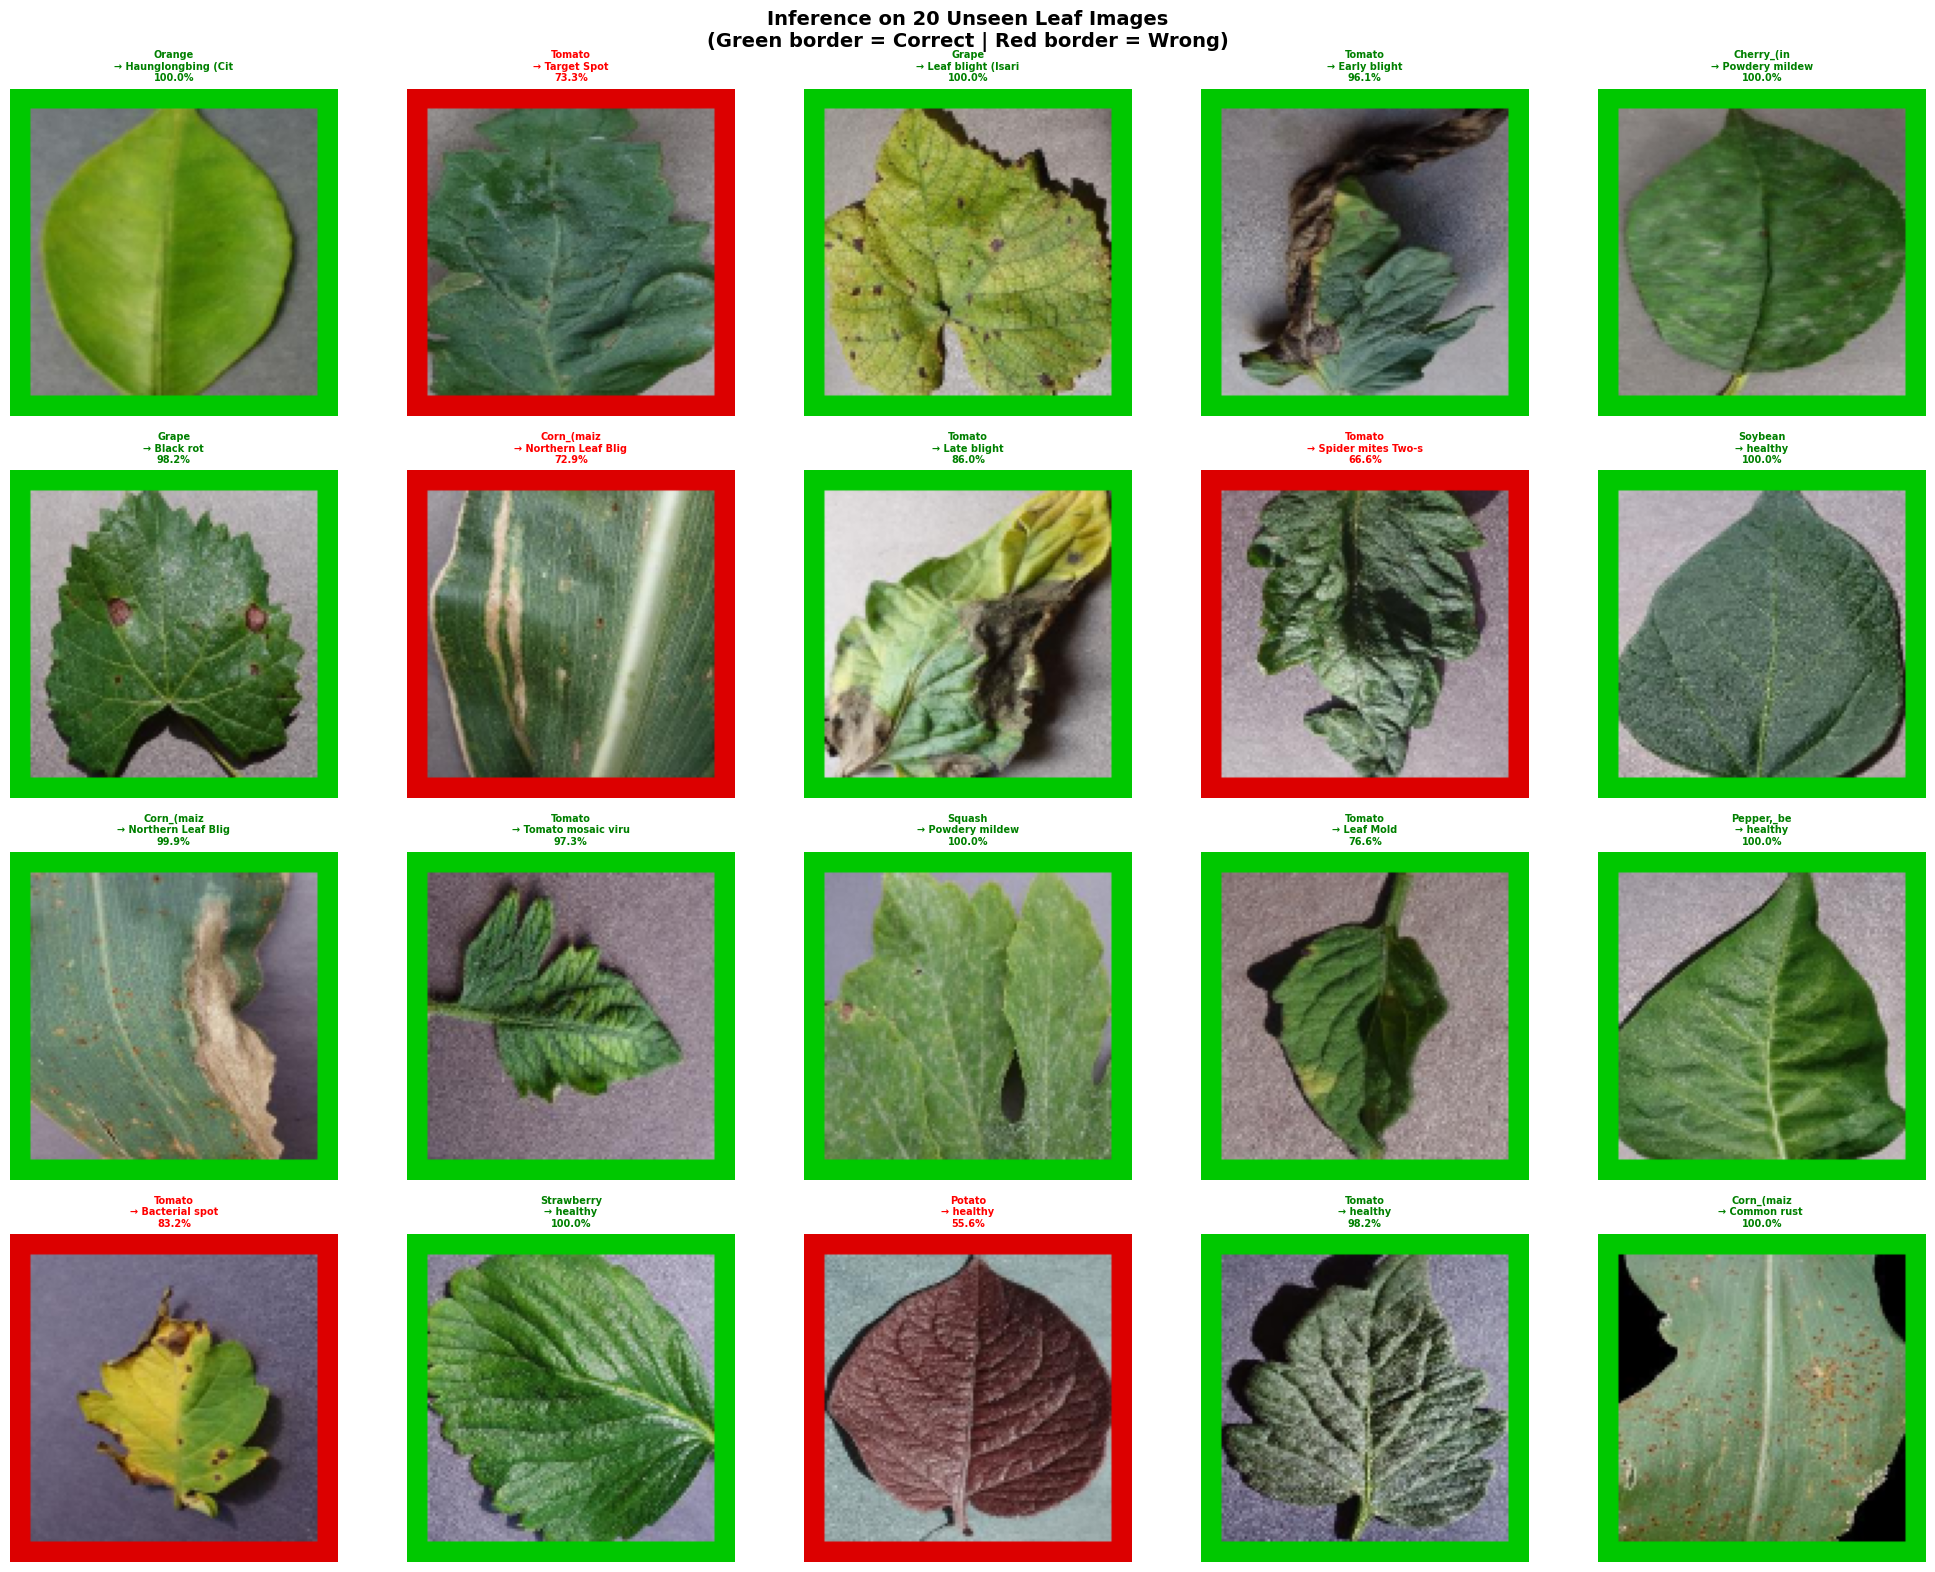

 Inference grid saved


In [ ]:
print("\n Running inference on 20 unseen leaf images...")

# Collect 20 random images (1 from each of 20 random classes)
selected_classes = random.sample(range(NUM_CLASSES), 20)
unseen_images, unseen_true_labels, unseen_paths = [], [], []

for cls_idx in selected_classes:
    cls_folder = os.path.join(VAL_DIR, class_names[cls_idx])
    all_files  = os.listdir(cls_folder)
    img_file   = random.choice(all_files)
    img_path   = os.path.join(cls_folder, img_file)

    img_bgr = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(cv2.resize(img_bgr, IMG_SIZE), cv2.COLOR_BGR2RGB)

    unseen_images.append(img_rgb)
    unseen_true_labels.append(cls_idx)
    unseen_paths.append(img_path)

# Predict
batch = np.array(unseen_images) / 255.0
probs = model.predict(batch, verbose=0)
pred_indices     = np.argmax(probs, axis=1)
pred_confidences = np.max(probs, axis=1) * 100

# ── Annotate with cv2.putText & save ──────────────────────────
annotated_dir = '/content/drive/MyDrive/PlantDisease/annotated_predictions'
os.makedirs(annotated_dir, exist_ok=True)

for i, (img_rgb, true_idx, pred_idx, conf) in enumerate(
        zip(unseen_images, unseen_true_labels, pred_indices, pred_confidences)):

    img_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)
    img_bgr = cv2.resize(img_bgr, (400, 400))

    # Background bar for text
    cv2.rectangle(img_bgr, (0, 0), (400, 70), (0, 0, 0), -1)

    pred_label  = class_names[pred_idx].replace('___', ' | ').replace('_', ' ')
    true_label  = class_names[true_idx].replace('___', ' | ').replace('_', ' ')
    is_correct  = (pred_idx == true_idx)
    color       = (0, 255, 0) if is_correct else (0, 0, 255)   # green=correct, red=wrong

    cv2.putText(img_bgr, f"Pred: {pred_label[:35]}",
                (5, 22), cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 1, cv2.LINE_AA)
    cv2.putText(img_bgr, f"Conf: {conf:.1f}%",
                (5, 44), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 255, 0), 1, cv2.LINE_AA)
    cv2.putText(img_bgr, f"True: {true_label[:35]}",
                (5, 65), cv2.FONT_HERSHEY_SIMPLEX, 0.40, (200, 200, 200), 1, cv2.LINE_AA)

    save_path = os.path.join(annotated_dir, f'pred_{i+1:02d}.jpg')
    cv2.imwrite(save_path, img_bgr)

print(f"20 annotated images saved to: {annotated_dir}")

# ── Display all 20 in a grid ──────────────────────────────────
fig, axes = plt.subplots(4, 5, figsize=(20, 16))
fig.suptitle('Inference on 20 Unseen Leaf Images\n(Green border = Correct | Red border = Wrong)',
             fontsize=14, fontweight='bold')

for i, ax in enumerate(axes.flatten()):
    img_disp   = unseen_images[i].copy()
    pred_name  = class_names[pred_indices[i]]
    true_name  = class_names[unseen_true_labels[i]]
    conf       = pred_confidences[i]
    correct    = (pred_indices[i] == unseen_true_labels[i])

    # Colored border
    border_color = [0, 200, 0] if correct else [220, 0, 0]
    img_disp[:8, :] = border_color
    img_disp[-8:, :] = border_color
    img_disp[:, :8] = border_color
    img_disp[:, -8:] = border_color

    ax.imshow(img_disp)

    pred_short = pred_name.split('___')[1].replace('_', ' ')[:18] if '___' in pred_name else pred_name[:18]
    true_short = true_name.split('___')[0][:10]

    ax.set_title(
        f"{true_short}\n→ {pred_short}\n{conf:.1f}%",
        fontsize=7,
        color='green' if correct else 'red',
        fontweight='bold'
    )
    ax.axis('off')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/PlantDisease/inference_20_images.png', dpi=130, bbox_inches='tight')
plt.show()
print(" Inference grid saved")

# Final Model Comparison


 Final Model Comparison Table
                 Model       Architecture       Trainable Params Total Params Val Accuracy (%)  Training Time(min)  Epochs Run   Optimizer
      CNN from Scratch 3-layer Custom CNN              8,492,838    8,493,798           82.84%                26.1           5 Adam (1e-3)
    MobileNetV2 Frozen MobileNetV2 + head                295,942    2,554,374           88.28%                28.3           5 Adam (1e-3)
MobileNetV2 Fine-Tuned MobileNetV2 + head ~1.1M (last 30 layers)    2,554,374           92.06%                26.1           5 Adam (1e-5)


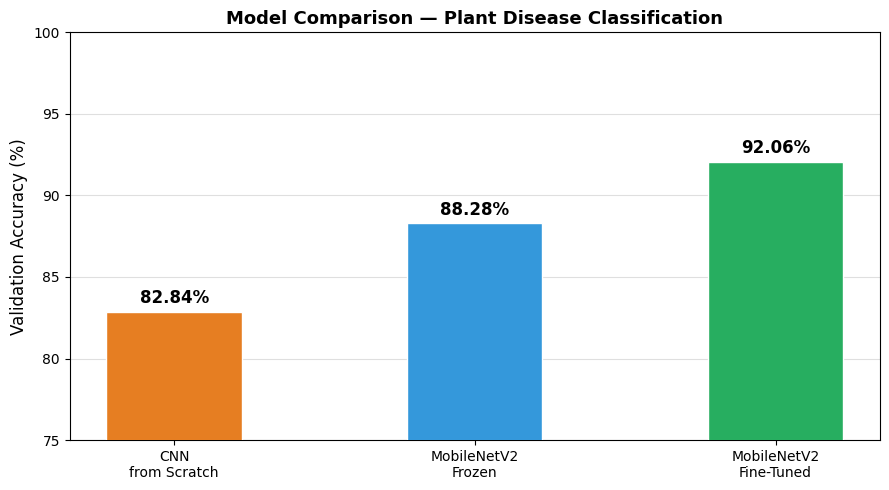

In [ ]:
print("\n Final Model Comparison Table")


comparison_data = {
    'Model':             ['CNN from Scratch',    'MobileNetV2 Frozen', 'MobileNetV2 Fine-Tuned'],
    'Architecture':      ['3-layer Custom CNN',  'MobileNetV2 + head', 'MobileNetV2 + head'],
    'Trainable Params':  ['8,492,838',           '295,942',            '~1.1M (last 30 layers)'],
    'Total Params':      ['8,493,798',           '2,554,374',          '2,554,374'],
    'Val Accuracy (%)':  [82.84,                 88.28,                92.06],
    'Training Time(min)':[26.1,                  28.3,                 26.1],
    'Epochs Run':        [5,                     5,                    5],
    'Optimizer':         ['Adam (1e-3)',          'Adam (1e-3)',         'Adam (1e-5)'],
}

comp_df = pd.DataFrame(comparison_data)
comp_df['Val Accuracy (%)'] = comp_df['Val Accuracy (%)'].apply(lambda x: f"{x:.2f}%")
print(comp_df.to_string(index=False))

# Visual comparison bar chart
fig, ax = plt.subplots(figsize=(9, 5))
models_list = ['CNN\nfrom Scratch', 'MobileNetV2\nFrozen', 'MobileNetV2\nFine-Tuned']
accs = [82.84, 88.28, 92.06]
bar_colors = ['#e67e22', '#3498db', '#27ae60']
bars = ax.bar(models_list, accs, color=bar_colors, edgecolor='white', width=0.45, zorder=3)
ax.set_ylim(75, 100)
ax.set_ylabel('Validation Accuracy (%)', fontsize=12)
ax.set_title('Model Comparison — Plant Disease Classification', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.4, zorder=0)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{acc:.2f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/PlantDisease/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Real Image Upload & Live Prediction Interface

 Upload your leaf image:


Saving leave_test.jfif to leave_test (2).jfif

🌿 Plant   : Apple
🦠 Disease : Apple scab
📊 Confidence: 95.43%


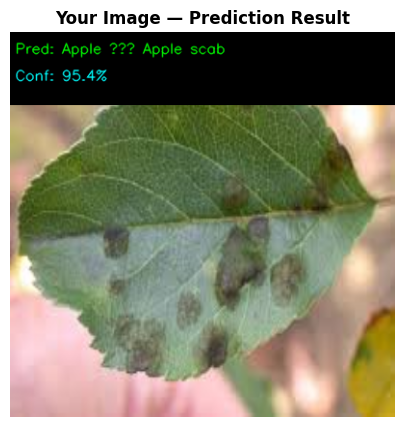

 Saved to Drive: /content/drive/MyDrive/PlantDisease/my_prediction_leave_test (2).jpg


In [ ]:
from google.colab import files
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os

# ── Upload your leaf image ──
print(" Upload your leaf image:")
uploaded = files.upload()

# ── Run prediction ──
for filename, content in uploaded.items():
    # Save uploaded file
    with open(filename, 'wb') as f:
        f.write(content)

    # Load and preprocess image
    img_bgr = cv2.imread(filename)
    img_rgb = cv2.cvtColor(cv2.resize(img_bgr, (128, 128)), cv2.COLOR_BGR2RGB)

    # Run model prediction
    batch = np.expand_dims(img_rgb / 255.0, axis=0)
    probs = model.predict(batch, verbose=0)
    pred_idx   = np.argmax(probs)
    confidence = np.max(probs) * 100
    pred_label = class_names[pred_idx].replace('___', ' → ').replace('_', ' ')

    # ── Print result ──
    print(f"\n{'='*45}")
    print(f"🌿 Plant   : {pred_label.split(' → ')[0]}")
    print(f"🦠 Disease : {pred_label.split(' → ')[1] if ' → ' in pred_label else 'N/A'}")
    print(f"📊 Confidence: {confidence:.2f}%")
    print(f"{'='*45}")

    # ── Annotate image and display ──
    img_show = cv2.resize(img_bgr, (400, 400))
    cv2.rectangle(img_show, (0, 0), (400, 75), (0,0,0), -1)
    color = (0, 255, 0) if confidence > 70 else (0, 165, 255)
    cv2.putText(img_show, f"Pred: {pred_label[:35]}", (5, 22),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1, cv2.LINE_AA)
    cv2.putText(img_show, f"Conf: {confidence:.1f}%", (5, 50),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 0), 1, cv2.LINE_AA)

    plt.figure(figsize=(5, 5))
    plt.imshow(cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title('Your Image — Prediction Result', fontweight='bold')
    plt.show()

    # ── Save annotated image to Drive ──
    clean_name = os.path.splitext(filename)[0]
    save_path = f'/content/drive/MyDrive/PlantDisease/my_prediction_{clean_name}.jpg'
    cv2.imwrite(save_path, img_show)
    print(f" Saved to Drive: {save_path}")

# Save All Models to Google Drive

In [ ]:
import shutil, os

os.makedirs('/content/drive/MyDrive/PlantDisease', exist_ok=True)

# Save all keras models
for file in os.listdir('/content/'):
    if file.endswith('.keras'):
        shutil.copy(f'/content/{file}', f'/content/drive/MyDrive/PlantDisease/{file}')
        print(f" Model saved: {file}")

print(" Location: MyDrive/PlantDisease/")

 Model saved: modelB_trainable.keras
 Model saved: modelA_frozen.keras
 Model saved: model_A_cnn_scratch.keras
 Location: MyDrive/PlantDisease/


In [ ]:
import shutil, os

os.makedirs('/content/drive/MyDrive/PlantDisease/my_predictions', exist_ok=True)

# Save all prediction images
for file in os.listdir('/content/'):
    if file.startswith('my_prediction') or file.endswith('.jpg') or file.endswith('.png'):
        shutil.copy(f'/content/{file}', f'/content/drive/MyDrive/PlantDisease/my_predictions/{file}')
        print(f"Saved: {file}")

print("\n All predictions saved!")
print(" MyDrive/PlantDisease/my_predictions/")

Saved: Leave.jpg

 All predictions saved!
 MyDrive/PlantDisease/my_predictions/
